In [89]:
import numpy as np 
import scipy.signal as signal
from scipy.interpolate import  RegularGridInterpolator
import matplotlib.pyplot as plt
import scipy


We are going to use welch to create a PSD estimate of the *whole combined data* this will be a gross overestimate, by ALOT, really what you want to do is to use a PSD ouptut from a global fit. 

In [90]:
# Where the preprocessed data is stored
preporcessing_directory = '/Users/diganta/Desktop/Papers/Mojito_search/Pre-processing/Data-preprocessing'

t_grid = np.load(preporcessing_directory + '/t_grid.npy')
f_grid = np.load(preporcessing_directory + '/f_grid.npy')

nT = len(t_grid) - 1
nF = len(f_grid)

# mojito_sft_data = np.load(preporcessing_directory + '/mojito_sft_data.npy')
mojito_td_data = np.load(preporcessing_directory + '/mojito_data.npy')

In [91]:
# Read in time-domain data 
times = mojito_td_data[0]
times = times - times[0] # Set the first time to zero

A = mojito_td_data[1]
E = mojito_td_data[2]
T = mojito_td_data[3]

dt = times[1] - times[0] # cadence of time-domain data

In [106]:
#Compute PSDs over 30 day timescales 
num_days_welch = 30
times_edges = np.arange(0,times[-1],num_days_welch*24*3600)
times_edges,times_edges.shape,times[-1]

(array([       0.,  2592000.,  5184000.,  7776000., 10368000., 12960000.,
        15552000., 18144000., 20736000., 23328000., 25920000., 28512000.,
        31104000., 33696000., 36288000., 38880000., 41472000., 44064000.,
        46656000., 49248000., 51840000., 54432000., 57024000., 59616000.,
        62208000.]),
 (25,),
 np.float64(63116195.000000015))

Use welch to calculate PSD for each segment, keep in mind welch PSDs will not have the same frequency shape, so we will need to do a re-interpolation in the next step onto the (t,f) grid being used for our search 

/var/folders/8g/7279dvmd20vd_b85_lr8pfh80000gp/T/ipykernel_2952/3288445580.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


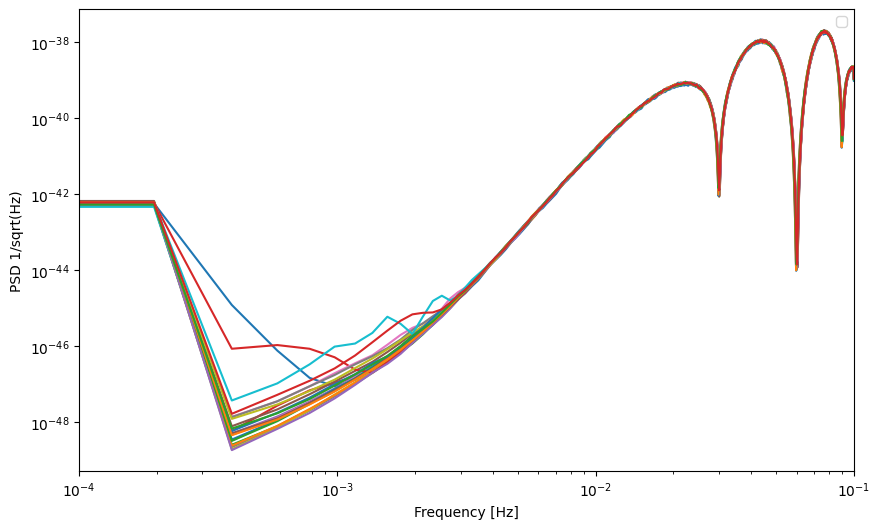

In [107]:

plt.figure(figsize=(10,6))

PSD_storage_A = []
PSD_storage_E = []
PSD_storage_T = []

for index in range(0, len(times_edges)-1):
    
    time_begin = times_edges[index]
    time_end = times_edges[index+1]
    indexes = (times >= time_begin) & (times < time_end)

    _f, PSD_A_welch =  scipy.signal.welch(A[indexes], fs=1.0/dt, window='hann', nperseg=32*32)
    _f, PSD_E_welch =  scipy.signal.welch(E[indexes], fs=1.0/dt, window='hann', nperseg=32*32)
    _f, PSD_T_welch =  scipy.signal.welch(T[indexes], fs=1.0/dt, window='hann', nperseg=32*32)
    PSD_storage_A.append(PSD_A_welch)
    PSD_storage_E.append(PSD_E_welch)
    PSD_storage_T.append(PSD_T_welch)

    plt.loglog(_f, PSD_T_welch)


plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD 1/sqrt(Hz)')
plt.xlim(1.e-4,1.e-1)

plt.legend()
plt.show()

In [94]:
times_edges.shape, _f_filtered.shape

((13,), (25,))

In [95]:
_f.shape

(513,)

<Figure size 1500x1000 with 0 Axes>

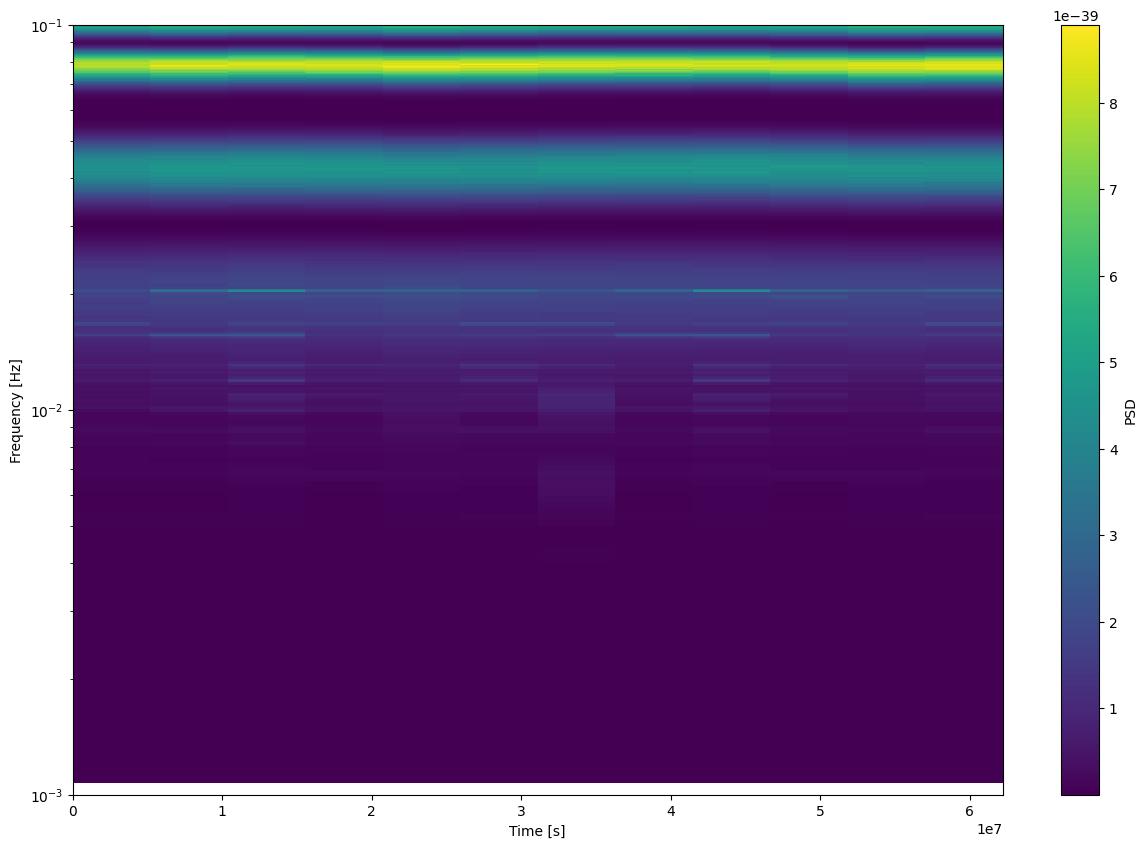

In [96]:
plt.figure(figsize=(15,10))
# f_mask = (_f>1.e-3) & (_f<6.e-3)

# _f_filtered = _f[f_mask]

C = np.array(PSD_storage_A).T  # shape: (n_freq, n_time_bins)
t_centers = 0.5 * (times_edges[:-1] + times_edges[1:])

# Remove DC bin
f_plot = _f[1:]
C_plot = C[1:, :]

# Keep only 1e-3 to 1e-1 Hz
fmin, fmax = 1e-3, 1.e-1
f_mask = (f_plot >= fmin) & (f_plot < fmax)
f_plot = f_plot[f_mask]
C_plot = C_plot[f_mask, :]

plt.figure(figsize=(15, 10))
mesh = plt.pcolormesh(t_centers, f_plot, C_plot, shading='nearest')
plt.yscale('log')
plt.ylim(fmin, fmax)
plt.colorbar(mesh, label='PSD')
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.savefig("PSD_combined_data.png", dpi=200, bbox_inches="tight")
plt.show()

In [97]:
PSD_storage_A = np.array(PSD_storage_A)
PSD_storage_E = np.array(PSD_storage_E)
PSD_storage_T = np.array(PSD_storage_T)

# Zero out DC components (not needed anyway)
PSD_storage_A[:,0] = 0.0
PSD_storage_E[:,0] = 0.0
PSD_storage_T[:,0] = 0.0


In [98]:
# Midpoint times of each Welch segment
t_centers = 0.5 * (times_edges[:-1] + times_edges[1:])

In [99]:

np.save('PSD_constant.npy',{'Type':'Constant',
                            'Frequencies':_f,
                                'Times':np.array(t_centers),
                                'A':PSD_storage_A,
                                'E':PSD_storage_E,
                                'T':PSD_storage_T})

In [100]:
!pwd

/Users/diganta/Desktop/Papers/Mojito_search/Pre-processing/Data-preprocessing


In [101]:
np.all(PSD_storage_A>=0)

np.True_